### Build A Basic Chatbot With Langgraph(GRAPH API)

In [44]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages


In [45]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]



In [46]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [47]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="groq:llama-3.3-70b-versatile")

In [48]:
llm

ChatGroq(profile={}, client=<groq.resources.chat.completions.Completions object at 0x000001F4A68FE660>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F4A68FE090>, model_name='groq:llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [49]:
llm=init_chat_model("groq:llama-3.3-70b-versatile")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F4A69AA5A0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F4A69AA030>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [50]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [51]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

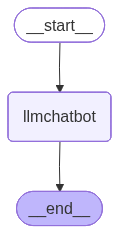

In [52]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [53]:
# Use square brackets [ ] to show it's a list!
response = graph.invoke({"messages": [("user", "Hi")]})


In [54]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [55]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you may have. How about you? How's your day going so far?


### Chatbot With Tool

In [56]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'response_time': 0.66,
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.datacamp.com/tutorial/langgraph-tutorial',
   'title': 'LangGraph Tutorial: What Is LangGraph and How to Use It?',
   'content': 'LangGraph is a library within the LangChain ecosystem that provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured and efficient manner. By managing the flow of data and the sequence of operations, LangGraph allows developers to focus on the high-level logic of their applications rather than the intricacies of agent coordination. Whether you need a chatbot that can handle various types of user requests or a multi-agent system that performs complex tasks, LangGraph provides the tools to build exactly what you need. LangGraph significantly simplifies the development of complex LLM applications by providing a structured framework for managing state and coordi

In [57]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [58]:
tools=[tool,multiply]

In [59]:
llm_with_tool=llm.bind_tools(tools)

In [60]:
llm_with_tool

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F4A69AA5A0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F4A69AA030>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input

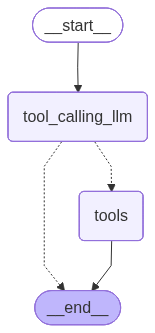

In [61]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))



In [62]:
response=graph.invoke({"messages":"What is the recent ai news"})

In [63]:
response['messages'][-1].content

'{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/video/2026/03/31/nvidias-web-of-ai-investments.html", "title": "Nvidia\'s web of AI investments - CNBC", "score": 0.9190633, "published_date": "Tue, 31 Mar 2026 15:32:33 GMT", "content": "# TechCheck. # Nvidia\'s web of AI investments. CNBC\'s Kristina Partsinevelos reports the latest news surrounding Nvidia.", "raw_content": null}, {"url": "https://letsdatascience.com/news/companies-push-employees-to-adopt-ai-94bd7b7e", "title": "Companies Push Employees to Adopt AI - Let\'s Data Science", "score": 0.86703575, "published_date": "Wed, 01 Apr 2026 13:48:00 GMT", "content": "1,500+ Questions · 15 Domains · Unlimited Audio. # Companies Push Employees to Adopt AI. On April 1, 2026, Business Insider reports that firms including Meta, Google, and JPMorgan are pushing employees to use AI tools through incentives and mandates. ## Scoring Rationale. Scored high for s

In [64]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (cr2afh2z3)
 Call ID: cr2afh2z3
  Args:
    query: recent ai news
    search_depth: basic
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/video/2026/03/31/nvidias-web-of-ai-investments.html", "title": "Nvidia's web of AI investments - CNBC", "score": 0.9190633, "published_date": "Tue, 31 Mar 2026 15:32:33 GMT", "content": "# TechCheck. # Nvidia's web of AI investments. CNBC's Kristina Partsinevelos reports the latest news surrounding Nvidia.", "raw_content": null}, {"url": "https://letsdatascience.com/news/companies-push-employees-to-adopt-ai-94bd7b7e", "ti

In [65]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (tpk9t6ss1)
 Call ID: tpk9t6ss1
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [66]:
# Try this simple question to see if the robot's search tool works!
response = graph.invoke({"messages": [("user", "Search for the latest AI news today")]})

# Now look at the answer! 📰🕵️‍♂️
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

Search for the latest AI news today
================================== Ai Message ==================================
Tool Calls:
  tavily_search (6x52kt8ev)
 Call ID: 6x52kt8ev
  Args:
    query: latest AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://letsdatascience.com/news/openai-signs-smartly-to-personalize-ads-282b2080", "title": "OpenAI Signs Smartly To Personalize Ads - Let's Data Science", "score": 0.5694942, "published_date": "Wed, 01 Apr 2026 11:17:41 GMT", "content": "1,500+ Questions · 15 Domains · Unlimited Audio. # OpenAI Signs Smartly To Personalize Ads. OpenAI signed Smartly as its first creative adtech partner on April 1, 2026, Business Insider reports, with Smartly piloting pers

### ReAct Agent Architecture

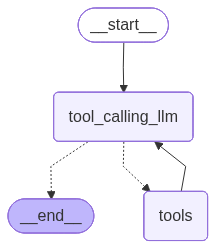

In [67]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [68]:
# Try this simple question to see if the robot's search tool works!
response = graph.invoke({"messages": [("user", "Search for the latest AI news today")]})

# Now look at the answer! 📰🕵️‍♂️
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

Search for the latest AI news today
================================== Ai Message ==================================
Tool Calls:
  tavily_search (2463pfa54)
 Call ID: 2463pfa54
  Args:
    query: latest AI news
    search_depth: basic
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://seekingalpha.com/news/4570770-ai-chip-stocks-jump-as-trump-hints-at-ending-iran-war-within-weeks", "title": "AI, chip stocks jump as Trump hints at ending Iran war within weeks - Seeking Alpha", "score": 0.9656413, "published_date": "Tue, 31 Mar 2026 15:48:29 GMT", "content": "Search for Symbols, analysts, keywords. # AI, chip stocks jump as Trump hints at ending Iran war within weeks. Follow us on Google for the latest stock

## Adding Memory In Agentic Graph

In [69]:
response=graph.invoke({"messages":"Hello my name is Manav, How are you Buddy ? Everthind is good ?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Manav, How are you Buddy ? Everthind is good ?
================================== Ai Message ==================================

I'm doing well, thanks for asking. However, I don't have personal experiences or emotions like humans do, so I don't have good or bad days. I'm here to help answer your questions and provide information to the best of my abilities. Is there something specific you'd like to know or discuss?


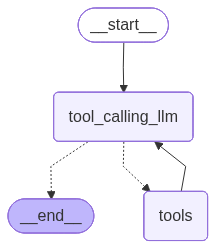

In [70]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [71]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Manav"},config=config)

response



{'messages': [HumanMessage(content='Hi my name is Manav', additional_kwargs={}, response_metadata={}, id='3fd5e3f3-b787-49b7-bf1e-c1df4fe9f7e3'),
  AIMessage(content="Hello Manav, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1751, 'total_tokens': 1778, 'completion_time': 0.09435074, 'completion_tokens_details': None, 'prompt_time': 0.116495436, 'prompt_tokens_details': None, 'queue_time': 0.318559609, 'total_time': 0.210846176}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_e65acd3773', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d49a3-f823-7222-a6bb-124ed6add463-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1751, 'output_tokens': 27, 'total_tokens': 1778})]}

In [72]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

Your name is Manav.


### Streaming

In [73]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [74]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

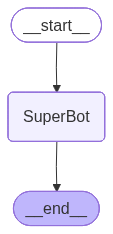

In [75]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [76]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='039b1aa5-4547-44b9-b67a-a33122a25ad2'),
  AIMessage(content="Hi Krish, nice to meet you. Cricket is an exciting sport, isn't it? Which team or player is your favorite? Are you more into international cricket or do you follow domestic leagues like the IPL?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 45, 'total_tokens': 88, 'completion_time': 0.1377869, 'completion_tokens_details': None, 'prompt_time': 0.018245162, 'prompt_tokens_details': None, 'queue_time': 0.090859127, 'total_time': 0.156032062}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d49a4-0a5f-72b2-bad7-9803bb4492aa-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_t

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

In [77]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Krish. Cricket is a fantastic sport, and I'm sure you must be excited about the various cricket tournaments and leagues happening around the world. Which team or player is your favorite? Do you play cricket yourself or just enjoy watching it?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 45, 'total_tokens': 98, 'completion_time': 0.184626125, 'completion_tokens_details': None, 'prompt_time': 0.014736652, 'prompt_tokens_details': None, 'queue_time': 0.199854497, 'total_time': 0.199362777}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d49a4-0bec-7830-8e3c-b445cb529c09-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 53, 'total_tokens': 98})]}}


In [78]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='82ce228f-fe6a-4a11-bcfe-ab082406a716'), AIMessage(content="Nice to meet you, Krish. Cricket is a fantastic sport, and I'm sure you must be excited about the various cricket tournaments and leagues happening around the world. Which team or player is your favorite? Do you play cricket yourself or just enjoy watching it?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 45, 'total_tokens': 98, 'completion_time': 0.184626125, 'completion_tokens_details': None, 'prompt_time': 0.014736652, 'prompt_tokens_details': None, 'queue_time': 0.199854497, 'total_time': 0.199362777}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d49a4-0bec-7830-8e3c-b445cb529c09-0', tool_calls=[], in

In [79]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Krish. Cricket is an exciting sport, and it's great that you're a fan. Are you a player yourself or do you enjoy watching matches, especially international ones like the ICC World Cup or the Indian Premier League (IPL)?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 45, 'total_tokens': 98, 'completion_time': 0.2504793, 'completion_tokens_details': None, 'prompt_time': 0.008134988, 'prompt_tokens_details': None, 'queue_time': 0.464825767, 'total_time': 0.258614288}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d49a4-109d-78f0-b5bb-986540e44381-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 53, 'total_tokens': 98})]}}


In [80]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='9be18b85-4b3b-41d5-a833-8d847415105c'), AIMessage(content="Nice to meet you, Krish. Cricket is an exciting sport, and it's great that you're a fan. Are you a player yourself or do you enjoy watching matches, especially international ones like the ICC World Cup or the Indian Premier League (IPL)?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 45, 'total_tokens': 98, 'completion_time': 0.2504793, 'completion_tokens_details': None, 'prompt_time': 0.008134988, 'prompt_tokens_details': None, 'queue_time': 0.464825767, 'total_time': 0.258614288}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d49a4-109d-78f0-b5bb-986540e44381-0', tool_calls=[], invalid_tool_calls=[], usag

In [81]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019d49a4-1594-7841-92a2-29cca844c970', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='d31e3cce-250a-434f-ad6d-53d1e37f2fb8')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019d49a4-1597-7be3-bc12-78a503b70330', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:20e78561-9546-08e2-ffea-95573ddb2f02'}, 'parent_ids': ['019d49a4-1594-7841-92a2-29cca844c970']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':

In [82]:
# Create a new notebook (thread) for our test!
config = {"configurable": {"thread_id": "99"}}

# The "Spy Window" Test: 
# We're going to ask the robot to do TWO big things at once. 🕵️‍♂️🔍
for chunk in graph_builder.stream(
    {"messages": [("user", "What is the latest AI news and then multiply 12 by 12")]},
    config, 
    stream_mode="updates"
):
    print("--- 🍕 NEW PIZZA STEP: ---")
    print(chunk)
    print("\n")


--- 🍕 NEW PIZZA STEP: ---
{'SuperBot': {'messages': [AIMessage(content="As of my knowledge cutoff in 2023, some of the latest AI news includes:\n\n1. **Advancements in Chatbots**: Many companies are developing more sophisticated chatbots that can understand and respond to complex queries, making customer service more efficient.\n2. **AI in Healthcare**: AI-powered algorithms are being used to diagnose diseases, develop personalized treatment plans, and improve patient outcomes.\n3. **Self-Driving Cars**: Tech companies like Waymo and Tesla are making significant progress in developing autonomous vehicles that can navigate roads safely and efficiently.\n4. **Quantum AI**: Researchers are exploring the potential of quantum computing to enhance AI capabilities, enabling faster and more complex calculations.\n\nNow, let's do some math:\n\n12 × 12 = 144\n\nPlease note that my knowledge may not be up-to-date, and there may have been significant developments in AI since my knowledge cutoff in

In [84]:
# 1. Build the Map (Drawing) 🗺️
agent_builder = StateGraph(State)
agent_builder.add_node("tool_calling_llm", tool_calling_llm)
agent_builder.add_node("tools", ToolNode(tools))

# 2. Add the Doors (Edges) 🚪
agent_builder.add_edge(START, "tool_calling_llm")
agent_builder.add_conditional_edges("tool_calling_llm", tools_condition)
agent_builder.add_edge("tools", "tool_calling_llm")

# 3. BUILD THE ROBOT (Compile) 🤖✅
# We will call it 'my_agent' so we don't mix it up with other maps!
my_agent = agent_builder.compile(checkpointer=memory)

# 4. Now the "Spy Window" Test! 🕵️‍♂️🔍
config = {"configurable": {"thread_id": "agent_test_99"}}

for chunk in my_agent.stream(
    {"messages": [("user", "What is the latest AI news plus multiply 5 by 5")]},
    config, 
    stream_mode="updates"
):
    print("--- 🍕 PIZZA STEP: ---")
    print(chunk)
    print("\n")


--- 🍕 PIZZA STEP: ---
{'tool_calling_llm': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'makk8w81x', 'function': {'arguments': '{"query":"latest AI news","search_depth":"basic","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}, {'id': '0x8y4gk0c', 'function': {'arguments': '{"a":5,"b":5}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 1758, 'total_tokens': 1807, 'completion_time': 0.148091222, 'completion_tokens_details': None, 'prompt_time': 0.355110617, 'prompt_tokens_details': None, 'queue_time': 0.200203459, 'total_time': 0.503201839}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d49a4-9e9b-7523-91e0-69281c460606-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'latest AI news', 'search_depth': 'basi